# Atividade - Lista Extra IA 
## Aluno: Nayron Campos Soares

Questão 01. Construa um pipeline de classificação para detecção de fraude. Use um modelo à sua
escolha dentre os vistos na disciplina (justifique a escolha) e mantenha o mesmo modelo e a mesma
semente aleatória em todas as comparações. Execute as etapas abaixo:

1. Análise exploratória: visualização do conjunto, tipos de dados, distribuição das variáveis e
proporção das classes.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

In [44]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [45]:
df.shape

(284807, 31)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [47]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

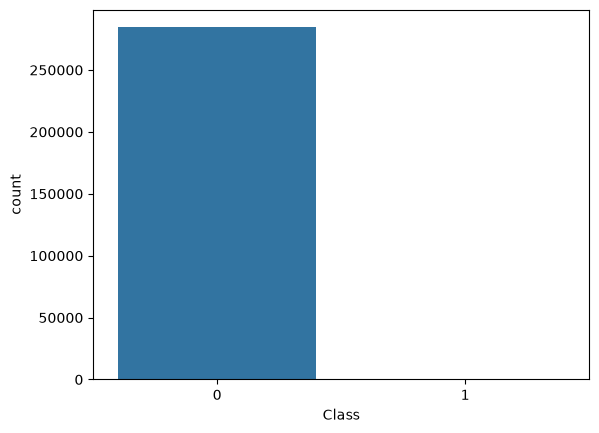

In [48]:
sns.countplot(x="Class", data=df)
plt.show()

Resposta = A função df.head() foi usada para visualizar as primeiras linhas do conjunto de dados. Em seguida, a função df.shape para ver a quantidade de linhas e colunas da base.

Depois usei a função df.info() para identificar os tipos dos atributos e a função df.describe() para obter estatísticas básicas dos dados.

Por fim, a distribuição das classes foi analisada utilizando df["Class"].value_counts() e um gráfico gerado com sns.countplot(). Pude observar um forte desbalanceamento entre as classes, com um número alto de transações não fraudulentas em relação às fraudulentas. Até mesmo no gráfico, a coluna do "1" nem aparece direito justamente por essa discrepância. Achei até ter feito errado kkkk, mas é por que a visualização é comprometida por essa distância dos valores mesmo. Pesquisei um comando, caso queira visualizar em escala logaritmica, tem esse comando abaixo:

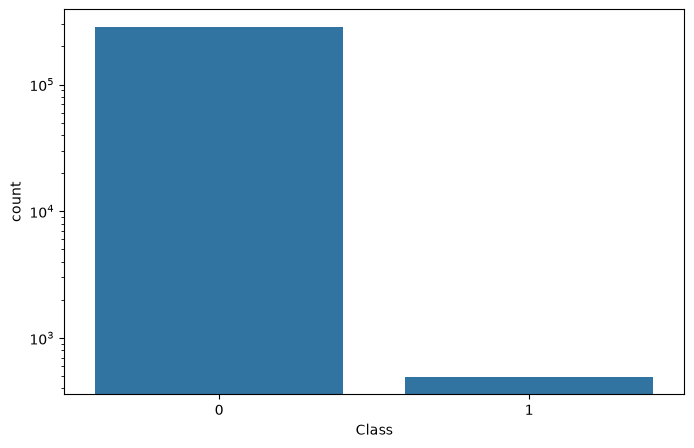

In [49]:
plt.figure(figsize=(8,5))
sns.countplot(x="Class", data=df)
plt.yscale("log")
plt.show()

2. Valores ausentes: verificação e, se houver, tratamento (descreva o método).

In [50]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Resposta = Para verificar a existência de valores ausentes foi utilizada a função `df.isnull().sum()`, que conta a quantidade de valores nulos em cada atributo. A análise mostrou que não existem valores ausentes na base de dados, portanto não foi necessário realizar nenhum tratamento adicional.


3. Redundância e inconsistência: detecção e remoção de registros duplicados ou
inconsistentes.

In [51]:
df.duplicated().sum()

np.int64(1081)

In [52]:
df = df.drop_duplicates()

In [53]:
df.duplicated().sum()

np.int64(0)

Resposta = Foi realizada uma verificação de registros duplicados utilizando a função df.duplicated().sum(). Depois foi utilizada a função df.drop_duplicates() para removê-las.

4. Análise de correlação e multicolinearidade: examine as correlações. Comente o efeito
esperado de V1–V28 serem componentes de PCA (logo, aproximadamente
descorrelacionados).

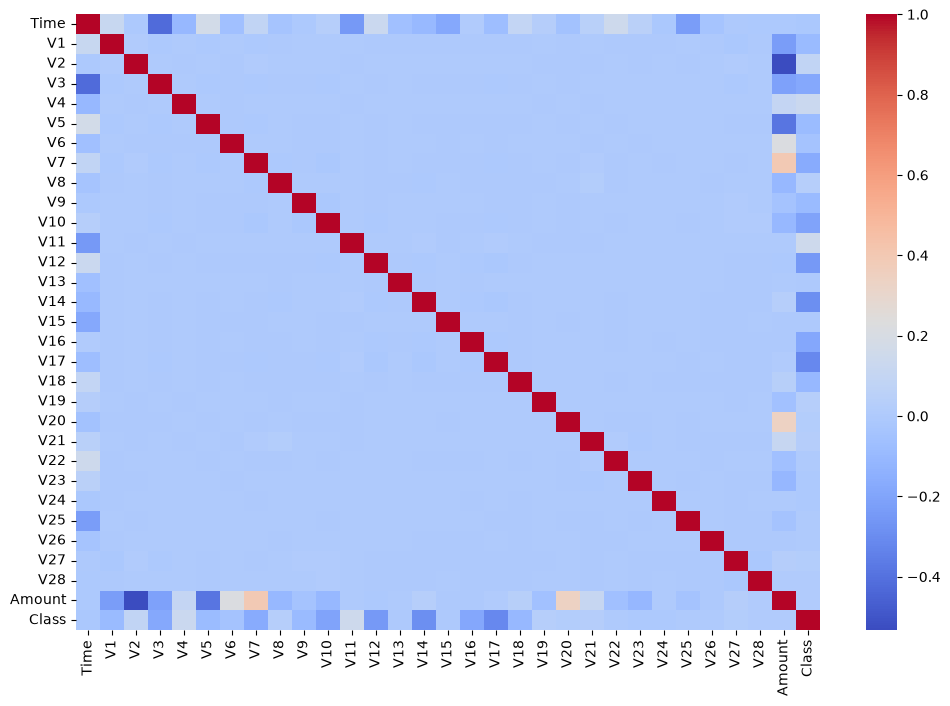

In [54]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()


Resposta = A análise de correlação foi realizada utilizando a função df.corr(), sendo os resultados visualizados através de um mapa de calor gerado com sns.heatmap(). Observou-se que as variáveis V1 a V28 apresentam baixa correlação entre si, o que já era esperado, pois esses atributos foram obtidos através da técnica PCA. Dessa forma, problemas de multicolinearidade tendem a ser reduzidos na base de dados.

    5. Divisão treino–teste estratificada: separe os dados (ex.: 70/30 ou 80/20) preservando a
    proporção de classes. Todas as etapas seguintes que aprendem parâmetros devem ser
    ajustadas apenas no conjunto de treino.


In [55]:
from sklearn.model_selection import train_test_split
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64

Resposta = Os dados foram divididos em conjuntos de treinamento e teste utilizando a função train_test_split(). Foi utilizada a opção stratify=y para preservar a proporção original entre transações fraudulentas e não fraudulentas em ambos os conjuntos. Neste trabalho, 80% dos dados foram destinados ao treinamento e 20% aos testes.

6. Outliers: analise a presença de outliers. Discuta se, em detecção de fraude, outliers podem
coincidir com a própria classe minoritária. Em outras palavras, justifique se devem ou não ser
removidos.


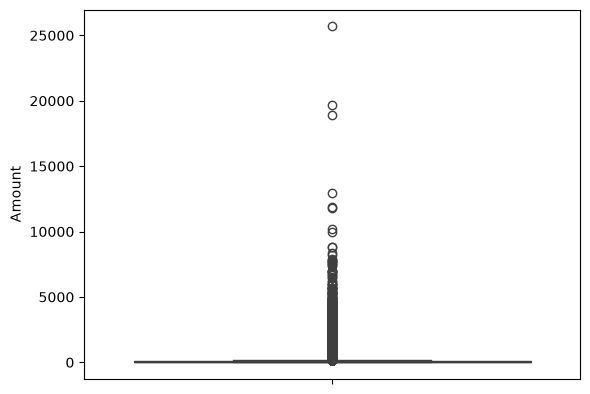

In [56]:
sns.boxplot(data=df["Amount"])
plt.show()

Resposta = A presença de outliers foi analisada por meio de gráficos do tipo Boxplot. Foram identificados diversos valores extremos, principalmente relacionados ao valor das transações. Entretanto, em problemas de detecção de fraude, observações extremas podem representar justamente os casos fraudulentos. Dessa forma, optou-se por não remover os outliers, evitando a perda de informações relevantes para a identificação de fraudes.

7. Normalização/padronização: padronize os atributos. Ajuste o scaler no treino e aplique-o
no teste.


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Resposta = Foi utilizada a classe `StandardScaler()` para padronizar os atributos da base. O método `fit_transform()` foi aplicado apenas ao conjunto de treinamento para calcular os parâmetros da transformação, enquanto o método `transform()` foi utilizado no conjunto de teste.


8. Codificação de variáveis: verifique se há variáveis categóricas. Caso não haja, explique por
que esta etapa não se aplica.


In [58]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Resposta = Foi realizada uma análise dos tipos de dados utilizando a função `df.dtypes`. Observou-se que todos os atributos da base já estão representados numericamente, não existindo variáveis categóricas. Logo não foi necessária a aplicação de técnicas de codificação

9. Balanceamento de classe: aplicado somente ao conjunto de treino. O conjunto de teste
deve permanecer com a distribuição original, para simular um cenário de dados reais.


In [59]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Resposta =

Antes:

In [60]:
y_train.value_counts()

Class
0    226602
1       378
Name: count, dtype: int64

Depois:

In [61]:
pd.Series(y_train_bal).value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

## Avaliação da Performance (Random Forest)

In [62]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    random_state=42
)

modelo.fit(
    X_train_bal,
    y_train_bal
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Foi utilizado o algoritmo Random Forest para a construção do classificador. A escolha desse modelo se deve à sua robustez, boa capacidade de generalização e bom desempenho em problemas de classificação com atributos numéricos.

O treinamento foi realizado utilizando o conjunto de treinamento balanceado através da técnica SMOTE, mantendo a mesma semente aleatória (random_state=42) para garantir a reprodutibilidade dos resultados.

O X_train_bal contem os valores (Time, Amount, V1 a V28) e o y_train_bal (valores de 0 e 1)

In [63]:
y_pred = modelo.predict(X_test_scaled)

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Acurácia: 0.9994889507630493
Precision: 0.9125
Recall: 0.7684210526315789
F1-Score: 0.8342857142857143


In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### Avaliação da Performance

Após o treinamento do modelo Random Forest, foram calculadas as métricas de desempenho utilizando o conjunto de teste.

A acurácia obtida foi de aproximadamente 99,95%. Entretanto, devido ao forte desbalanceamento da base de dados, foram analisadas também as métricas Precision, Recall e F1-Score da classe minoritária (fraudes).

O modelo apresentou Precision de 91,25%, indicando que a maioria das transações classificadas como fraude realmente correspondia a casos fraudulentos. O Recall foi de 76,84%, mostrando que o modelo conseguiu identificar grande parte das fraudes existentes, embora algumas ainda não tenham sido detectadas.

O F1-Score obtido foi de 83,43%, demonstrando um bom equilíbrio entre Precision e Recall. De forma geral, os resultados indicam que o modelo apresentou bom desempenho na detecção de fraudes, sendo capaz de identificar a maior parte das transações fraudulentas com baixa taxa de falsos positivos.

In [ ]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

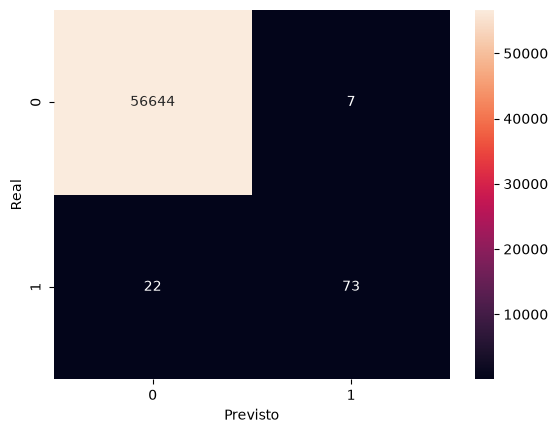

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

Matriz de Confusão

A matriz de confusão foi utilizada para analisar detalhadamente os acertos e erros do classificador. Essa representação permite identificar a quantidade de transações fraudulentas corretamente detectadas e aquelas que foram classificadas incorretamente como legítimas.

Questão 2. Aplique os algoritmos K-Means e DBSCAN sobre os dados sem o atributo Class (o
rótulo não é utilizado em agrupamentos) e compare os resultados.
● Para reduzir o custo computacional do agrupamento, utilize uma amostra de 10% do
conjunto de treino.
● Utilize os atributos padronizados na questão anterior.
● K-Means: encontre o melhor valor de k (ex.: método do cotovelo variando k entre 2 e 5) e
reporte os resultados.
● DBSCAN: utilize os valores padrão de eps e min_samples. Note que o número de clusters é
descoberto pelo algoritmo (não imposto) e reporte quantos grupos e quantos outliers foram
encontrados.


In [78]:
from sklearn.utils import resample

X_sample = resample(
    X_train_scaled,
    replace=False,
    n_samples=int(len(X_train_scaled) * 0.10),
    random_state=42
)

print(X_sample.shape)

(22698, 30)


### Amostragem

Conforme solicitado, foi utilizada uma amostra correspondente a 10% do conjunto de treinamento. Essa estratégia reduz o custo computacional dos algoritmos de agrupamento sem comprometer significativamente a representatividade dos dados.


In [79]:
from sklearn.cluster import KMeans

sse = []

for k in range(2, 6):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)

    sse.append(kmeans.inertia_)
    print(sse)

[666439.5277458165]
[666439.5277458165, 643060.6754267812]
[666439.5277458165, 643060.6754267812, 624088.8684721915]
[666439.5277458165, 643060.6754267812, 624088.8684721915, 606095.7691428905]


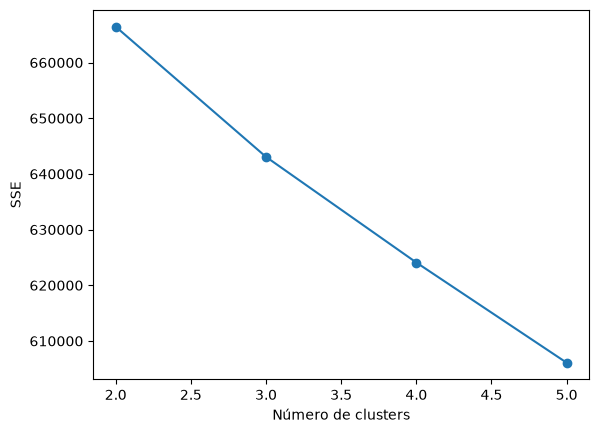

In [70]:
plt.plot(range(2,6), sse, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("SSE")
plt.show()

Para determinar o número adequado de clusters, foi aplicado o método do cotovelo variando o valor de k entre 2 e 5. A métrica utilizada foi a Soma dos Erros Quadráticos (SSE).

Observou-se uma redução contínua do SSE à medida que o número de clusters aumentava. Embora não tenha sido identificado um cotovelo muito pronunciado, verificou-se que a taxa de redução do SSE passou a diminuir a partir de k=4.

Dessa forma, foi escolhido o valor k=4 para a execução final do algoritmo K-Means.

In [80]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X_sample)

print(clusters_kmeans)

[1 2 2 ... 0 0 0]


In [81]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(
    X_sample,
    clusters_kmeans
)

print("Silhouette:", silhouette_kmeans)
print("SSE:", kmeans.inertia_)

Silhouette: 0.07629736219146561
SSE: 624088.8684721915


### Resultados do K-Means

O agrupamento resultou em quatro clusters. A Soma dos Erros Quadráticos (SSE) obtida foi de aproximadamente 624088,87.

O coeficiente de silhueta calculado foi de 0,0763. Esse valor indica que os grupos encontrados apresentam baixa separação entre si.

In [82]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()

clusters_db = dbscan.fit_predict(
    X_sample
)
print(clusters_db)

[ 0 -1 -1 ... -1 -1 -1]


In [83]:
n_clusters = len(set(clusters_db))

if -1 in clusters_db:
    n_clusters -= 1

outliers = np.sum(clusters_db == -1)


print("Clusters:", n_clusters)
print("Outliers:", outliers)

Clusters: 99
Outliers: 21349


In [84]:
from sklearn.metrics import silhouette_score

if len(set(clusters_db)) > 1:
    print(
        "Silhouette:",
        silhouette_score(X_sample, clusters_db)
    )

Silhouette: -0.4014864456724828


## K-Means Vs DBSCAN

### K-Means

Para determinar o número de clusters, foi utilizado o método do cotovelo variando k entre 2 e 5. Observou-se uma redução gradual da Soma dos Erros Quadráticos (SSE), sendo escolhido k=4 para a execução final.

O agrupamento apresentou SSE igual a 624088,87 e coeficiente de silhueta igual a 0,0763. Embora o valor da silhueta seja baixo, indicando grupos pouco separados, o resultado ainda sugere uma estrutura de agrupamento mais consistente que a obtida pelo DBSCAN.

### DBSCAN

O DBSCAN foi executado utilizando os parâmetros padrão (eps=0.5 e min_samples=5). O algoritmo identificou automaticamente 99 clusters e classificou 21349 registros como outliers.

O coeficiente de silhueta obtido foi de -0,4015, indicando baixa qualidade dos agrupamentos encontrados. Além disso, a elevada quantidade de outliers sugere que os parâmetros padrão não foram adequados para representar a estrutura dos dados neste conjunto.

### Conclusão

Comparando os dois métodos, o K-Means apresentou melhor desempenho, obtendo coeficiente de silhueta superior ao do DBSCAN e produzindo agrupamentos mais consistentes. O DBSCAN mostrou dificuldade em identificar regiões densas na base analisada, classificando grande parte dos registros como ruído.